In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/insurance.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (1338, 7)


In [2]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [3]:
print("Null counts:")
print(df.isna().sum())

print("\nUnique-value counts:")
print(df.nunique())

Null counts:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Unique-value counts:
age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


## Dataset Selection

**Dataset:** Medical Cost Personal Dataset

**Source:** Kaggle — Medical Cost Personal Datasets  
https://www.kaggle.com/datasets/mirichoi0218/insurance

**License:** Public domain / Open Database, Contents: Database Contents

I chose this dataset because it contains more than 200 observations and includes both numeric and categorical variables. It is suitable for exploring how factors such as age, smoking status, BMI, and region relate to medical insurance charges, while also providing useful opportunities for GroupBy aggregation, merging, reshaping, NumPy-based computation, and visualization.

In [4]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 1


In [5]:

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


In [6]:
print("Missing values after cleaning:")
print(df.isna().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

Missing values after cleaning:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows after cleaning: 0


## Data Cleaning Decisions

The dataset contained no missing values, so no imputation or deletion for missing data was necessary. One exact duplicate row was found and removed because it did not provide additional information. The remaining columns already had appropriate data types for the planned analysis, so no unnecessary dtype conversions were applied.

In [7]:
# Grouping by smoking status shows the typical insurance charges for smokers and non-smokers.
print("Shape before GroupBy:", df.shape)

smoker_stats = (
    df.groupby("smoker")["charges"]
    .agg(["mean", "median"])
    .reset_index()
)

print("\nGrouped statistics:")
print(smoker_stats)

Shape before GroupBy: (1337, 7)

Grouped statistics:
  smoker          mean       median
0     no   8440.660307   7345.72660
1    yes  32050.231832  34456.34845


In [8]:
# Merging group statistics back onto each row lets us compare an individual's charge with their smoker group's typical charge.
print("Shape before merge:", df.shape)

df = df.merge(
    smoker_stats,
    on="smoker",
    how="left",
    suffixes=("", "_smoker_group")
)

print("Shape after merge:", df.shape)
print(df.head())

Shape before merge: (1337, 7)
Shape after merge: (1337, 9)
   age     sex     bmi  children smoker     region      charges          mean  \
0   19  female  27.900         0    yes  southwest  16884.92400  32050.231832   
1   18    male  33.770         1     no  southeast   1725.55230   8440.660307   
2   28    male  33.000         3     no  southeast   4449.46200   8440.660307   
3   33    male  22.705         0     no  northwest  21984.47061   8440.660307   
4   32    male  28.880         0     no  northwest   3866.85520   8440.660307   

        median  
0  34456.34845  
1   7345.72660  
2   7345.72660  
3   7345.72660  
4   7345.72660  


In [9]:
df = df.rename(
    columns={
        "mean": "smoker_group_mean_charge",
        "median": "smoker_group_median_charge"
    }
)

print(df.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'smoker_group_mean_charge', 'smoker_group_median_charge']


In [10]:
# A pivot table compares average insurance charges across region and smoking status.
print("Shape before pivot:", df.shape)

charge_pivot = pd.pivot_table(
    df,
    values="charges",
    index="region",
    columns="smoker",
    aggfunc="mean"
)

print("\nAverage charges by region and smoking status:")
print(charge_pivot)

print("\nShape after pivot:", charge_pivot.shape)

Shape before pivot: (1337, 9)

Average charges by region and smoking status:
smoker              no           yes
region                              
northeast  9165.531672  29673.536473
northwest  8582.467101  30192.003182
southeast  8032.216309  34844.996824
southwest  8019.284513  32269.063494

Shape after pivot: (4, 2)


In [11]:
print("Final DataFrame shape:", df.shape)
print("\nFirst five rows:")
print(df.head())

Final DataFrame shape: (1337, 9)

First five rows:
   age     sex     bmi  children smoker     region      charges  \
0   19  female  27.900         0    yes  southwest  16884.92400   
1   18    male  33.770         1     no  southeast   1725.55230   
2   28    male  33.000         3     no  southeast   4449.46200   
3   33    male  22.705         0     no  northwest  21984.47061   
4   32    male  28.880         0     no  northwest   3866.85520   

   smoker_group_mean_charge  smoker_group_median_charge  
0              32050.231832                 34456.34845  
1               8440.660307                  7345.72660  
2               8440.660307                  7345.72660  
3               8440.660307                  7345.72660  
4               8440.660307                  7345.72660  


In [12]:
charges_array = df["charges"].to_numpy()

print("Array type:", type(charges_array))
print("Array shape:", charges_array.shape)
print("First five values:", charges_array[:5])

Array type: <class 'numpy.ndarray'>
Array shape: (1337,)
First five values: [16884.924    1725.5523   4449.462   21984.47061  3866.8552 ]


In [13]:
charges_mean = charges_array.mean()
charges_std = charges_array.std()

charges_standardized = (charges_array - charges_mean) / charges_std

print("Mean of standardized charges:", charges_standardized.mean())
print("Standard deviation:", charges_standardized.std())
print("Minimum:", charges_standardized.min())
print("Maximum:", charges_standardized.max())

Mean of standardized charges: -1.00974659532101e-16
Standard deviation: 1.0
Minimum: -1.0042473509293852
Maximum: 4.1708257119553585


In [14]:
df["charges_standardized"] = charges_standardized

print("DataFrame shape after adding the NumPy feature:", df.shape)
print(df[["charges", "charges_standardized"]].head())

DataFrame shape after adding the NumPy feature: (1337, 10)
       charges  charges_standardized
0  16884.92400              0.297857
1   1725.55230             -0.954381
2   4449.46200             -0.729373
3  21984.47061              0.719104
4   3866.85520             -0.777499


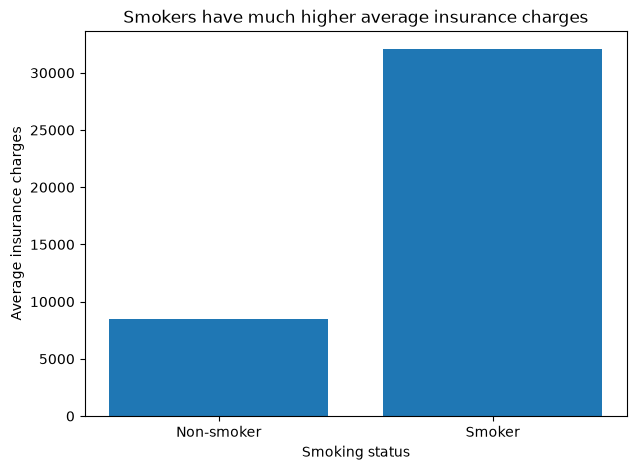

In [15]:
smoker_charges = df.groupby("smoker")["charges"].mean()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-smoker", "Smoker"],
    [smoker_charges["no"], smoker_charges["yes"]]
)

plt.xlabel("Smoking status")
plt.ylabel("Average insurance charges")
plt.title("Smokers have much higher average insurance charges")
plt.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")
plt.show()

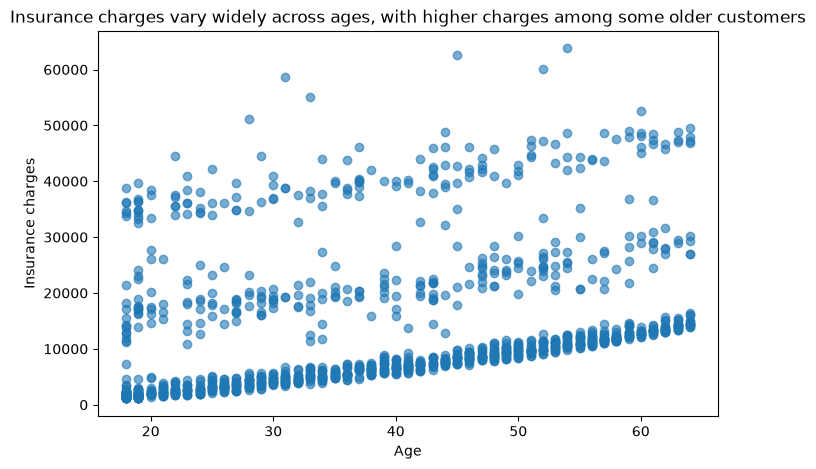

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["age"],
    df["charges"],
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Insurance charges")
plt.title("Insurance charges vary widely across ages, with higher charges among some older customers")
plt.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Save the cleaned and feature-engineered dataset for later use.
df.to_csv("../data/processed/insurance_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Shape:", df.shape)

Cleaned dataset saved successfully.
Shape: (1337, 10)
